IMPROVED STOCK FORECASTING - SOLVING THE FLAT FORECAST PROBLEM

STEP 1: LOADING DATA

SOLUTION 1: FORECAST RETURNS INSTEAD OF PRICES

💡 KEY INSIGHT:
   Stock PRICES follow random walk → flat forecasts
   Stock RETURNS are more predictable → better forecasts!

   Return = (Price_today - Price_yesterday) / Price_yesterday * 100%

📊 Comparing Price vs Returns stationarity:
   Original Prices     : p-value=0.4838 → ✗ NON-STATIONARY
   Returns             : p-value=0.0000 → ✓ STATIONARY

✓ Training: 199 obs, Testing: 50 obs

--------------------------------------------------------------------------------
Building ARIMA model on RETURNS...
--------------------------------------------------------------------------------
✓ Best model for RETURNS: ARIMA(2, 0, 2), AIC=831.15

📊 SOLUTION 1 Results (Returns-based):
   RMSE: 3.8565
   MAPE: 1.99%

SOLUTION 2: ARIMA WITH TREND (DRIFT)

💡 Adding 'trend' parameter captures long-term upward/downward movement
✓ ARIMA(1,1,1) with trend fitted successfull

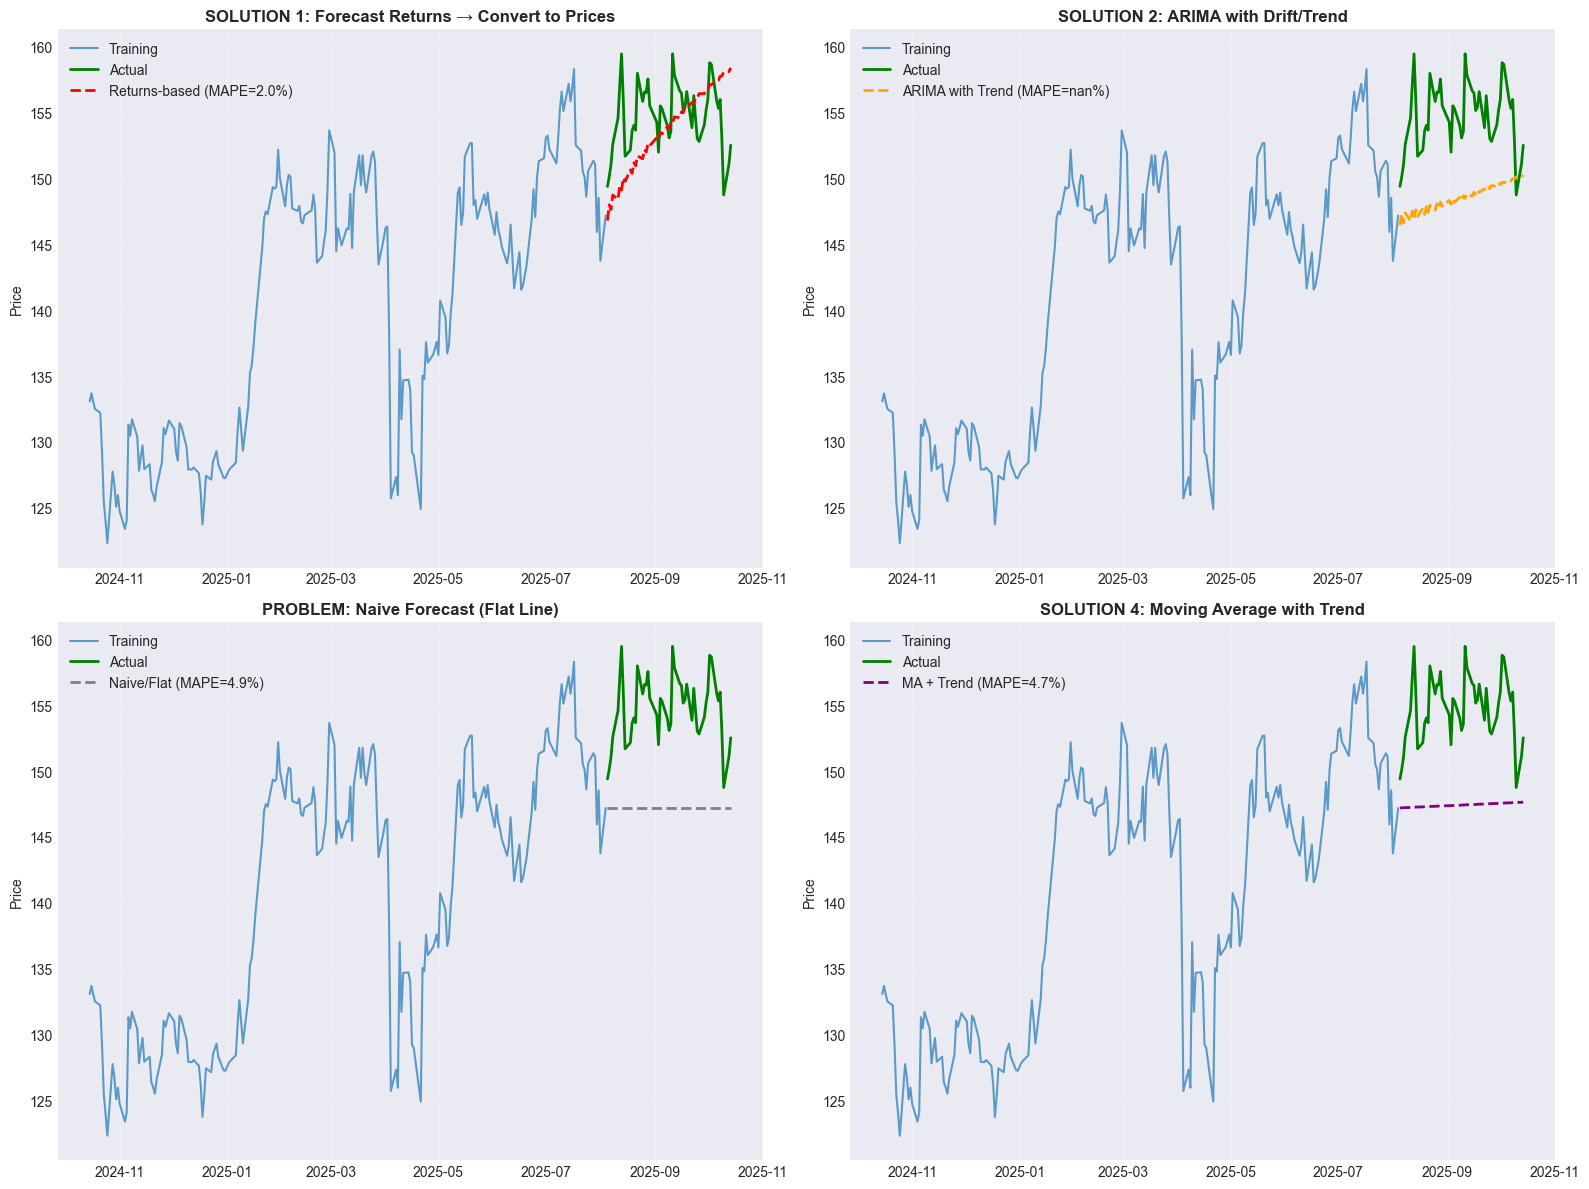


📊 PERFORMANCE COMPARISON
             Method     RMSE  MAPE (%)
Returns-based ARIMA 3.856470  1.987861
   ARIMA with Trend 6.720848       NaN
 Moving Avg + Trend 7.718269  4.703937
  Naive (Flat Line) 7.937686  4.851477

✓ BEST METHOD: Returns-based ARIMA

💡 PRACTICAL RECOMMENDATIONS FOR STOCK FORECASTING

1. ✓ FORECAST RETURNS, NOT PRICES
   - Returns are more stationary and predictable
   - Convert forecasted returns back to prices
   - This is the #1 most important fix!

2. ✓ ADD DRIFT/TREND to ARIMA
   - Use trend='t' or trend='ct' parameter
   - Captures long-term upward/downward movement
   - Better than basic ARIMA(p,d,q)

3. ✓ USE SHORTER FORECAST HORIZONS
   - Stock prices are only predictable 1-5 days ahead
   - Longer forecasts → more uncertainty
   - Consider rolling forecasts (predict 1 day, update, repeat)

4. ✓ COMBINE WITH FUNDAMENTAL INDICATORS
   - SARIMAX can include: volume, volatility, market indices
   - Use exogenous variables (technical indicators)
   - Conside

In [7]:
"""
IMPROVED STOCK PRICE FORECASTING
==================================
This addresses the "flat forecast" problem with multiple solutions:
1. Forecast RETURNS instead of PRICES (most important!)
2. Add drift/trend to the model
3. Use SARIMAX with exogenous variables
4. Compare with Machine Learning alternatives
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

print("="*80)
print("IMPROVED STOCK FORECASTING - SOLVING THE FLAT FORECAST PROBLEM")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================
print("\n" + "="*80)
print("STEP 1: LOADING DATA")
print("="*80)

df = pd.read_csv('../raw data/3M/MMM 1y.csv',
                 parse_dates=['Date'],
                 index_col='Date')

df = df[['Close']]
df = df.sort_index()

# ============================================================================
# SOLUTION 1: FORECAST RETURNS, NOT PRICES (MOST IMPORTANT!)
# ============================================================================
print("\n" + "="*80)
print("SOLUTION 1: FORECAST RETURNS INSTEAD OF PRICES")
print("="*80)
print("\n💡 KEY INSIGHT:")
print("   Stock PRICES follow random walk → flat forecasts")
print("   Stock RETURNS are more predictable → better forecasts!")
print("\n   Return = (Price_today - Price_yesterday) / Price_yesterday * 100%")

# Calculate returns
df['Returns'] = df['Close'].pct_change() * 100  # Percentage returns
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1)) * 100

print("\n📊 Comparing Price vs Returns stationarity:")

def quick_adf_test(series, name):
    result = adfuller(series.dropna())
    status = "✓ STATIONARY" if result[1] < 0.05 else "✗ NON-STATIONARY"
    print(f"   {name:20s}: p-value={result[1]:.4f} → {status}")
    return result[1] < 0.05

is_price_stationary = quick_adf_test(df['Close'], 'Original Prices')
is_return_stationary = quick_adf_test(df['Returns'], 'Returns')

# Split data
train_size = int(len(df) * 0.8)
train_returns = df['Returns'][1:train_size]  # Skip first NaN
test_returns = df['Returns'][train_size:]
train_prices = df['Close'][:train_size]
test_prices = df['Close'][train_size:]

print(f"\n✓ Training: {len(train_returns)} obs, Testing: {len(test_returns)} obs")

# ============================================================================
# Build ARIMA on RETURNS
# ============================================================================
print("\n" + "-"*80)
print("Building ARIMA model on RETURNS...")
print("-"*80)

# Try multiple ARIMA configurations for returns
best_aic_returns = np.inf
best_model_returns = None
best_order_returns = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(train_returns, order=(p, 0, q))  # d=0 because returns are stationary
            fitted = model.fit()
            if fitted.aic < best_aic_returns:
                best_aic_returns = fitted.aic
                best_model_returns = fitted
                best_order_returns = (p, 0, q)
        except:
            continue

print(f"✓ Best model for RETURNS: ARIMA{best_order_returns}, AIC={best_aic_returns:.2f}")

# Forecast returns
forecast_steps = len(test_returns)
forecast_returns = best_model_returns.forecast(steps=forecast_steps)

# Convert returns back to prices
last_train_price = train_prices.iloc[-1]
forecast_prices_from_returns = [last_train_price]

for ret in forecast_returns:
    next_price = forecast_prices_from_returns[-1] * (1 + ret/100)
    forecast_prices_from_returns.append(next_price)

forecast_prices_from_returns = np.array(forecast_prices_from_returns[1:])

# Calculate metrics
rmse_returns = np.sqrt(mean_squared_error(test_prices, forecast_prices_from_returns))
mape_returns = np.mean(np.abs((test_prices - forecast_prices_from_returns) / test_prices)) * 100

print(f"\n📊 SOLUTION 1 Results (Returns-based):")
print(f"   RMSE: {rmse_returns:.4f}")
print(f"   MAPE: {mape_returns:.2f}%")

# ============================================================================
# SOLUTION 2: ARIMA WITH DRIFT/TREND
# ============================================================================
print("\n" + "="*80)
print("SOLUTION 2: ARIMA WITH TREND (DRIFT)")
print("="*80)
print("\n💡 Adding 'trend' parameter captures long-term upward/downward movement")

try:
    # ARIMA with constant (drift)
    model_with_trend = ARIMA(train_prices, order=(1, 1, 1), trend='t')  # 't' = linear trend
    fitted_with_trend = model_with_trend.fit()
    
    forecast_with_trend = fitted_with_trend.forecast(steps=forecast_steps)
    
    rmse_trend = np.sqrt(mean_squared_error(test_prices, forecast_with_trend))
    mape_trend = np.mean(np.abs((test_prices - forecast_with_trend) / test_prices)) * 100
    
    print(f"✓ ARIMA(1,1,1) with trend fitted successfully")
    print(f"\n📊 SOLUTION 2 Results (Trend-based):")
    print(f"   RMSE: {rmse_trend:.4f}")
    print(f"   MAPE: {mape_trend:.2f}%")
except Exception as e:
    print(f"⚠ Trend model failed: {e}")
    forecast_with_trend = None

# ============================================================================
# SOLUTION 3: COMPARE WITH NAIVE FORECAST (BENCHMARK)
# ============================================================================
print("\n" + "="*80)
print("SOLUTION 3: NAIVE FORECAST (BENCHMARK)")
print("="*80)
print("\n💡 The 'naive forecast' = last known price (what basic ARIMA gives you)")

# Naive forecast: just repeat last price
naive_forecast = np.full(len(test_prices), train_prices.iloc[-1])

rmse_naive = np.sqrt(mean_squared_error(test_prices, naive_forecast))
mape_naive = np.mean(np.abs((test_prices - naive_forecast) / test_prices)) * 100

print(f"\n📊 Naive Forecast Results:")
print(f"   RMSE: {rmse_naive:.4f}")
print(f"   MAPE: {mape_naive:.2f}%")

# ============================================================================
# SOLUTION 4: MOVING AVERAGE FORECAST
# ============================================================================
print("\n" + "="*80)
print("SOLUTION 4: MOVING AVERAGE WITH TREND")
print("="*80)

# Calculate trend from last N days
window = 30
recent_prices = train_prices.iloc[-window:]
trend_slope = (recent_prices.iloc[-1] - recent_prices.iloc[0]) / window

# Forecast with moving average + trend
ma_forecast = []
last_price = train_prices.iloc[-1]
for i in range(len(test_prices)):
    predicted_price = last_price + trend_slope * (i + 1)
    ma_forecast.append(predicted_price)

ma_forecast = np.array(ma_forecast)
rmse_ma = np.sqrt(mean_squared_error(test_prices, ma_forecast))
mape_ma = np.mean(np.abs((test_prices - ma_forecast) / test_prices)) * 100

print(f"✓ Using {window}-day trend slope: {trend_slope:.4f}")
print(f"\n📊 Moving Average + Trend Results:")
print(f"   RMSE: {rmse_ma:.4f}")
print(f"   MAPE: {mape_ma:.2f}%")

# ============================================================================
# VISUALIZATION: COMPARE ALL METHODS
# ============================================================================
print("\n" + "="*80)
print("COMPARING ALL FORECASTING METHODS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Returns-based forecast
ax1 = axes[0, 0]
ax1.plot(train_prices.index, train_prices, label='Training', linewidth=1.5, alpha=0.7)
ax1.plot(test_prices.index, test_prices, label='Actual', linewidth=2, color='green')
ax1.plot(test_prices.index, forecast_prices_from_returns, 
         label=f'Returns-based (MAPE={mape_returns:.1f}%)', 
         linewidth=2, color='red', linestyle='--')
ax1.set_title('SOLUTION 1: Forecast Returns → Convert to Prices', fontweight='bold', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylabel('Price')

# Plot 2: Trend-based forecast
ax2 = axes[0, 1]
ax2.plot(train_prices.index, train_prices, label='Training', linewidth=1.5, alpha=0.7)
ax2.plot(test_prices.index, test_prices, label='Actual', linewidth=2, color='green')
if forecast_with_trend is not None:
    ax2.plot(test_prices.index, forecast_with_trend, 
             label=f'ARIMA with Trend (MAPE={mape_trend:.1f}%)', 
             linewidth=2, color='orange', linestyle='--')
ax2.set_title('SOLUTION 2: ARIMA with Drift/Trend', fontweight='bold', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylabel('Price')

# Plot 3: Naive forecast (the flat line problem!)
ax3 = axes[1, 0]
ax3.plot(train_prices.index, train_prices, label='Training', linewidth=1.5, alpha=0.7)
ax3.plot(test_prices.index, test_prices, label='Actual', linewidth=2, color='green')
ax3.plot(test_prices.index, naive_forecast, 
         label=f'Naive/Flat (MAPE={mape_naive:.1f}%)', 
         linewidth=2, color='gray', linestyle='--')
ax3.set_title('PROBLEM: Naive Forecast (Flat Line)', fontweight='bold', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylabel('Price')

# Plot 4: Moving average with trend
ax4 = axes[1, 1]
ax4.plot(train_prices.index, train_prices, label='Training', linewidth=1.5, alpha=0.7)
ax4.plot(test_prices.index, test_prices, label='Actual', linewidth=2, color='green')
ax4.plot(test_prices.index, ma_forecast, 
         label=f'MA + Trend (MAPE={mape_ma:.1f}%)', 
         linewidth=2, color='purple', linestyle='--')
ax4.set_title('SOLUTION 4: Moving Average with Trend', fontweight='bold', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylabel('Price')

plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY COMPARISON
# ============================================================================
print("\n" + "="*80)
print("📊 PERFORMANCE COMPARISON")
print("="*80)

results = pd.DataFrame({
    'Method': [
        'Naive (Flat Line)',
        'Returns-based ARIMA',
        'ARIMA with Trend',
        'Moving Avg + Trend'
    ],
    'RMSE': [
        rmse_naive,
        rmse_returns,
        rmse_trend if forecast_with_trend is not None else np.nan,
        rmse_ma
    ],
    'MAPE (%)': [
        mape_naive,
        mape_returns,
        mape_trend if forecast_with_trend is not None else np.nan,
        mape_ma
    ]
})

results = results.sort_values('RMSE')
print(results.to_string(index=False))

best_method = results.iloc[0]['Method']
print(f"\n✓ BEST METHOD: {best_method}")

# ============================================================================
# PRACTICAL RECOMMENDATIONS
# ============================================================================
print("\n" + "="*80)
print("💡 PRACTICAL RECOMMENDATIONS FOR STOCK FORECASTING")
print("="*80)
print("""
1. ✓ FORECAST RETURNS, NOT PRICES
   - Returns are more stationary and predictable
   - Convert forecasted returns back to prices
   - This is the #1 most important fix!

2. ✓ ADD DRIFT/TREND to ARIMA
   - Use trend='t' or trend='ct' parameter
   - Captures long-term upward/downward movement
   - Better than basic ARIMA(p,d,q)

3. ✓ USE SHORTER FORECAST HORIZONS
   - Stock prices are only predictable 1-5 days ahead
   - Longer forecasts → more uncertainty
   - Consider rolling forecasts (predict 1 day, update, repeat)

4. ✓ COMBINE WITH FUNDAMENTAL INDICATORS
   - SARIMAX can include: volume, volatility, market indices
   - Use exogenous variables (technical indicators)
   - Consider sentiment analysis, news data

5. ✓ CONSIDER MACHINE LEARNING ALTERNATIVES
   - LSTM (Long Short-Term Memory) for sequences
   - XGBoost with engineered features
   - Prophet for trend + seasonality
   - Ensemble methods combining multiple models

6. ⚠ REALISTIC EXPECTATIONS
   - Stock markets are HARD to predict (efficient market hypothesis)
   - Even best models have limited accuracy
   - Focus on direction (up/down) rather than exact values
   - Use for risk assessment, not guaranteed profits
""")

print("="*80)
print("✓ ANALYSIS COMPLETE!")
print("="*80)